# Modern Bayesian Workflow: Pyro guides, VI, predictive checks, and NumPyro

**ProbAI 2026 — Day 1 afternoon code session**

We will look at a probabilistic linear regression example,

$
y = 3 + 2x + \epsilon,
$

but exapand the viewpoint: a probabilistic model becomes an **executable probabilistic program**.

The modeling process becomes:

$
\text{specify} \rightarrow \text{guide} \rightarrow \text{optimize} \rightarrow
\text{predict} \rightarrow \text{criticize} \rightarrow \text{revise}.
$


## Learning goals

By the end, you should be able to:

1. read `sample`, `plate`, and `obs` as an executable version of a graphical model;
2. explain what a Pyro **guide** represents;
3. derive and interpret the ELBO used by stochastic variational inference (SVI);
4. have some ideas for diagnostics and predictive model checks;

In [2]:
# Colab/local setup. Existing packages are left untouched.
import importlib
import subprocess
import sys


def ensure_package(import_name, pip_name=None):
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already available")
    except ImportError:
        package = pip_name or import_name
        print(f"Installing {package} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


ensure_package("torch")
ensure_package("pyro", "pyro-ppl")
ensure_package("jax", "jax[cpu]")
ensure_package("numpyro")
ensure_package("matplotlib")
ensure_package("pandas")

✓ torch already available
Installing pyro-ppl ...
✓ jax already available
Installing numpyro ...
✓ matplotlib already available
✓ pandas already available


In [3]:
import random

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import pyro
import pyro.distributions as dist
import torch

from numpyro.infer import Predictive as NumPyroPredictive
from numpyro.infer import SVI as NumPyroSVI
from numpyro.infer import Trace_ELBO as NumPyroTraceELBO
from numpyro.infer.autoguide import AutoNormal as NumPyroAutoNormal
from numpyro.optim import Adam as NumPyroAdam
from pyro.infer import Predictive, SVI, Trace_ELBO
from pyro.infer.autoguide import AutoMultivariateNormal, AutoNormal
from torch.distributions import constraints

torch.set_default_dtype(torch.float32)
pyro.set_rng_seed(7)
np.random.seed(7)
random.seed(7)

print("Pyro:", pyro.__version__)
print("PyTorch:", torch.__version__)
print("NumPyro:", numpyro.__version__)
print("JAX:", jax.__version__)

Pyro: 1.9.1
PyTorch: 2.11.0+cpu
NumPyro: 0.21.0
JAX: 0.7.2


## 1. Notation

The full regression model is written using

$$
\mathbf x_i=[1,x_i]^\top, \qquad
Y_i\mid\mathbf w,\mathbf x_i \sim
\mathrm N(\mathbf w^\top\mathbf x_i,\gamma^{-1}),
\qquad \mathbf w\sim\mathrm N(\mathbf 0,I).
$$

We keep $\mathbf w=(a,b)$, and write the observation scale as
$\sigma=\gamma^{-1/2}$ and infer it:

$$
\mathbf w\sim\mathrm N(\mathbf 0,s_w^2I),\qquad
\sigma\sim\operatorname{LogNormal}(m_\sigma,s_\sigma),\qquad
Y_i\mid\mathbf w,\sigma,x_i\sim\mathrm N(w_0+w_1x_i,\sigma^2).
$$

The notation express the uncertainty in the noise scale.

## 2. Linear-regression generator

Consider $a=3$, $b=2$, $x\in[-3,3]$, and Gaussian noise with standard deviation 2.
We use a linea-regression generator with fewer observations so the live SVI fits finish quickly.

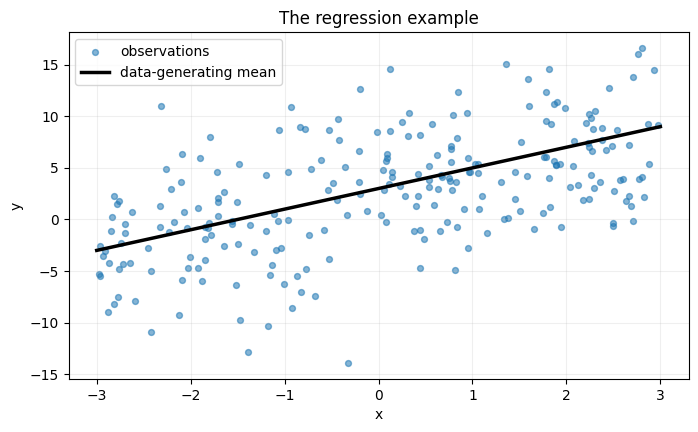

In [4]:
def make_regression(n=240, a=3.0, b=2.0, sigma=5.0, seed=7):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-3.0, 3.0, n).astype("float32")
    y = (a + b * x + rng.normal(0.0, sigma, n)).astype("float32")
    return x, y

x_np, y_np = make_regression()
x = torch.as_tensor(x_np)
y = torch.as_tensor(y_np)

grid = np.linspace(-3, 3, 200)
plt.figure(figsize=(8, 4.5))
plt.scatter(x_np, y_np, s=18, alpha=0.55, label="observations")
plt.plot(grid, 3 + 2 * grid, color="black", linewidth=2.5, label="data-generating mean")
plt.xlabel("x")
plt.ylabel("y")
plt.title("The regression example")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 3. The Pyro model: distribution, trace, and shapes

`pyro.sample` names random choices. `obs=y` conditions the `obs` site on data.
`to_event(1)` says that the two coordinates of $\mathbf w$ form one vector-valued event.
`plate("data", N)` says the $N$ observations are conditionally independent.

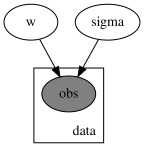

In [29]:
def regression_model(x, y=None, weight_scale=2.5):
    x = torch.as_tensor(x)
    y = None if y is None else torch.as_tensor(y)

    w = pyro.sample(
        "w",
        dist.Normal(torch.zeros(2), weight_scale * torch.ones(2)).to_event(1),
    )
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 0.5))
    mean = w[0] + w[1] * x

    with pyro.plate("data", x.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

pyro.render_model(model=regression_model, model_args=(x, y))

In [24]:
# Inspect one conditioned execution trace.
trace = pyro.poutine.trace(regression_model).get_trace(x, y)
trace.compute_log_prob()
print(trace.format_shapes())

Trace Shapes:        
 Param Sites:        
Sample Sites:        
       w dist     | 2
        value     | 2
     log_prob     |  
   sigma dist     |  
        value     |  
     log_prob     |  
    data dist     |  
        value 240 |  
     log_prob     |  
     obs dist 240 |  
        value 240 |  
     log_prob 240 |  


### Read the shape table

- `w` has event shape `(2,)`: it is one two-dimensional latent variable.
- `sigma` is scalar.
- `obs` has batch shape `(N,)` inside the data plate and scalar event shape.

This is the tensor version of the morning plate diagram.

## 4. Prior predictive checking happens before inference

Calling the model with `y=None` runs the generator. We compare an intentionally broad prior with the working prior.
If the generated datasets are implausible, no optimizer can repair the model specification.

We will use `Predictive` class to create a predictive distribution that takes a model as input and number of samples.

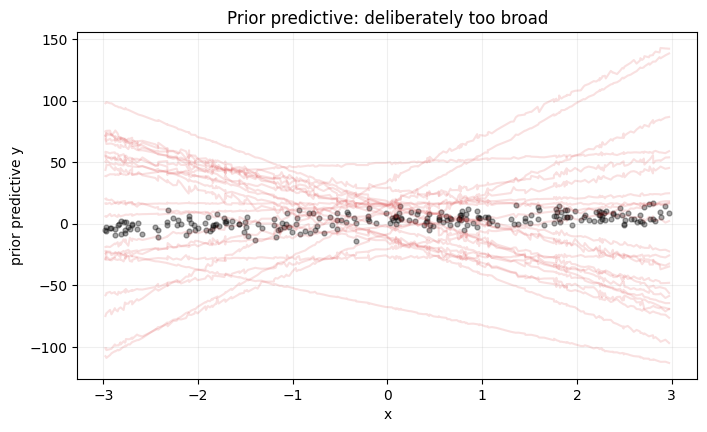

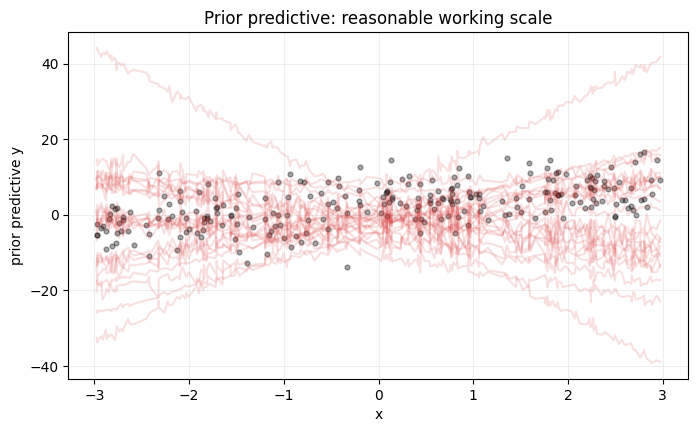

[]

In [30]:
def plot_prior_predictive(weight_scale, title, num_lines=24):
    pyro.clear_param_store()
    pred = Predictive(regression_model, num_samples=80)
    draws = pred(x, None, weight_scale=weight_scale)["obs"].detach().cpu().numpy()
    order = np.argsort(x_np)

    plt.figure(figsize=(8, 4.5))
    for row in draws[:num_lines]:
        plt.plot(x_np[order], row[order], color="tab:red", alpha=0.14)
    plt.scatter(x_np, y_np, s=12, color="black", alpha=0.35, label="observed later")
    plt.xlabel("x")
    plt.ylabel("prior predictive y")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


plot_prior_predictive(20.0, "Prior predictive: deliberately too broad")
plot_prior_predictive(5.5, "Prior predictive: reasonable working scale")



## 5. Technical dive: what is a guide?

The model defines $p(\mathrm D,\theta)$. A guide defines an executable approximation
$q_\phi(\theta\mid\mathrm D)$.

A guide must make explicit choices about:

- factorization and dependence;
- marginal distribution families;
- support transformations;
- learnable variational parameters;
- conditioning on data (especially for amortized inference).

The following mean-field guide assumes independent variational factors for $\mathbf w$ and $\sigma$, and independent coordinates within $\mathbf w$.

In [32]:
def mean_field_guide(x, y=None, weight_scale=2.5):
    w_loc = pyro.param("w_loc", torch.zeros(2))
    w_scale = pyro.param(
        "w_scale",
        0.1 * torch.ones(2),
        constraint=constraints.positive,
    )
    sigma_loc = pyro.param("sigma_loc", torch.tensor(0.0))
    sigma_scale = pyro.param(
        "sigma_scale",
        torch.tensor(0.1),
        constraint=constraints.positive,
    )

    pyro.sample("w", dist.Normal(w_loc, w_scale).to_event(1))
    pyro.sample("sigma", dist.LogNormal(sigma_loc, sigma_scale))

### Model–guide contract

The guide's latent sample-site names (`w`, `sigma`), supports, and event dimensions match the model.
The observed `obs` site is absent from the guide because the guide approximates the distribution of **unobserved** latent variables.

`AutoNormal(regression_model)` automates this construction: for each continuous latent site it creates a Normal factor in an unconstrained space, then maps samples back to the site's support. It is convenient, but still mean-field.

In [33]:
def fit_svi(model, guide, x, y, num_steps=900, lr=0.03):
    pyro.clear_param_store()
    svi = SVI(model, guide, pyro.optim.Adam({"lr": lr}), loss=Trace_ELBO())
    losses = []
    for _ in range(num_steps):
        losses.append(svi.step(x, y) / len(x))
    return losses


def plot_loss(losses, title):
    plt.figure(figsize=(7, 3.8))
    plt.plot(losses)
    plt.xlabel("SVI step")
    plt.ylabel("negative ELBO / observation")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()




[]

## 6. ELBO and SVI

For any guide $q_\phi$,

$$
\log p(\mathrm D)
=E_{q_\phi}\left[
\log p(\mathrm D,\theta)-\log q_\phi(\theta)
\right]
+\mathrm{KL}\!\left(q_\phi(\theta)\|p(\theta\mid\mathrm D)\right).
$$
and separating
$$
\mathrm L(\phi) = E_{q_\phi}\left[
\log p(\mathrm D,\theta)-\log q_\phi(\theta)
\right]
$$

`Trace_ELBO` estimates $\mathrm L(\phi)$ by tracing the model and guide. `SVI.step` samples, scores, differentiates, and updates $\phi$.

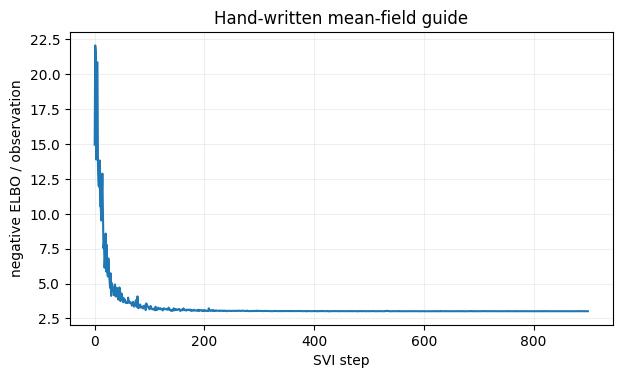

[('w_loc', tensor([2.4509, 1.8199], requires_grad=True)),
 ('w_scale', tensor([0.2862, 0.1860], grad_fn=<AddBackward0>)),
 ('sigma_loc', tensor(1.5479, requires_grad=True)),
 ('sigma_scale', tensor(0.0610, grad_fn=<AddBackward0>))]

In [34]:
# Fit the explicit guide first so its assumptions and parameters remain visible.
losses_manual = fit_svi(regression_model, mean_field_guide, x, y)
plot_loss(losses_manual, "Hand-written mean-field guide")

manual_params = {
    name: value.detach().cpu().numpy().copy()
    for name, value in pyro.get_param_store().items()
}
pd.DataFrame(
    {
        "parameter": list(manual_params),
        "value": [np.asarray(v).round(3) for v in manual_params.values()],
    }
)

list(pyro.get_param_store().items())


In [35]:
# Draw from the fitted guide immediately, before clearing Pyro's global parameter store.
manual_predictive = Predictive(
    regression_model,
    guide=mean_field_guide,
    num_samples=500,
    return_sites=("w", "sigma", "obs"),
)
manual_draws = manual_predictive(x, None)

print("Posterior mean of w = (intercept, slope):",
      manual_draws["w"].mean(0).detach().cpu().numpy().round(3))
print("Posterior mean of sigma:",
      float(manual_draws["sigma"].mean().detach().cpu()))

Posterior mean of w = (intercept, slope): [[2.455 1.814]]
Posterior mean of sigma: 4.7001190185546875


### Auto-guides make alternative geometry easy to try

- `AutoNormal`: separate Normal factors by site (mean-field).
- `AutoMultivariateNormal`: a full-covariance Gaussian over the continuous latent space.

The richer guide can represent posterior correlation, but costs more and still cannot represent multimodality.
For the live path we fit `AutoNormal`; the full-covariance variant is one line to try later.

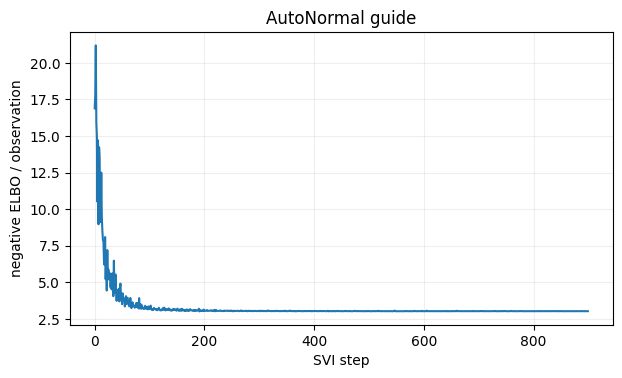

In [36]:
pyro.clear_param_store()
auto_guide = AutoNormal(regression_model)
losses_auto = fit_svi(regression_model, auto_guide, x, y)
plot_loss(losses_auto, "AutoNormal guide")

auto_predictive = Predictive(
    regression_model,
    guide=auto_guide,
    num_samples=500,
    return_sites=("w", "sigma", "obs"),
)
auto_draws = auto_predictive(x, None)

# Optional richer family:
# rich_guide = AutoMultivariateNormal(regression_model)

## 7. Posterior predictive checking

An improving ELBO is an optimization diagnostic. It is not evidence that the likelihood is scientifically adequate.
We now compare observed data with replicated datasets generated from the fitted model.

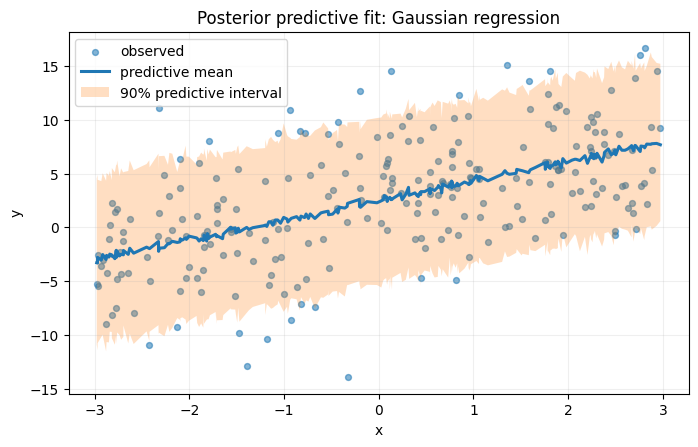

In [37]:
def plot_predictive_fit(x_values, y_values, obs_draws, title):
    x_values = np.asarray(x_values)
    y_values = np.asarray(y_values)
    obs_draws = np.asarray(obs_draws)
    order = np.argsort(x_values)
    mean = obs_draws.mean(axis=0)[order]
    lo = np.quantile(obs_draws, 0.05, axis=0)[order]
    hi = np.quantile(obs_draws, 0.95, axis=0)[order]

    plt.figure(figsize=(8, 4.7))
    plt.scatter(x_values, y_values, s=18, alpha=0.55, label="observed")
    plt.plot(x_values[order], mean, linewidth=2.2, label="predictive mean")
    plt.fill_between(x_values[order], lo, hi, alpha=0.25, label="90% predictive interval")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_predictive_fit(
    x_np,
    y_np,
    auto_draws["obs"].detach().cpu().numpy(),
    "Posterior predictive fit: Gaussian regression",
)

## 8. Deliberate failure: contaminate the regression with outliers

The mean function remains linear. The failure is in the observation model: one Gaussian scale must explain both regular points and extreme residuals.

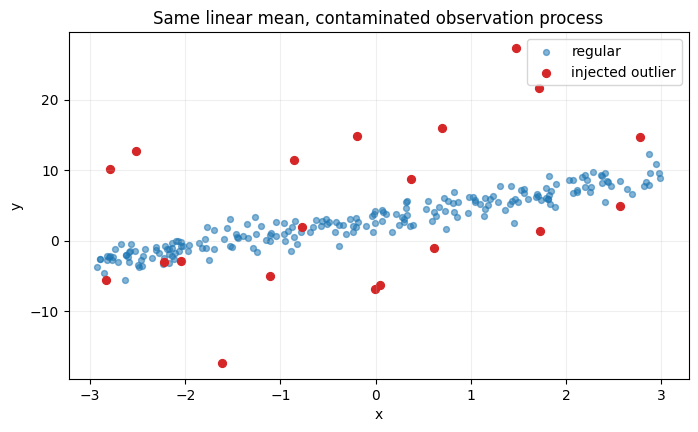

In [15]:
def make_outlier_regression(n=340, a=3.0, b=2.0, sigma=1.2,
                            outlier_probability=0.08, outlier_sigma=10.0, seed=11):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-3.0, 3.0, n).astype("float32")
    y = a + b * x + rng.normal(0.0, sigma, n)
    is_outlier = rng.uniform(size=n) < outlier_probability
    y[is_outlier] += rng.normal(0.0, outlier_sigma, is_outlier.sum())
    return x, y.astype("float32"), is_outlier


x_out_np, y_out_np, outlier_mask = make_outlier_regression()
x_out = torch.as_tensor(x_out_np)
y_out = torch.as_tensor(y_out_np)

plt.figure(figsize=(8, 4.5))
plt.scatter(x_out_np[~outlier_mask], y_out_np[~outlier_mask], s=18, alpha=0.55, label="regular")
plt.scatter(x_out_np[outlier_mask], y_out_np[outlier_mask], s=32, color="tab:red", label="injected outlier")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Same linear mean, contaminated observation process")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

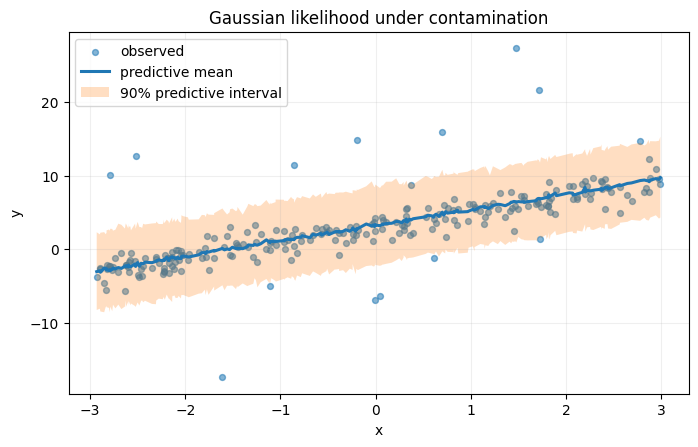

In [16]:
pyro.clear_param_store()
gaussian_guide = AutoNormal(regression_model)
gaussian_losses = fit_svi(regression_model, gaussian_guide, x_out, y_out, num_steps=1000)
gaussian_predictive = Predictive(
    regression_model,
    guide=gaussian_guide,
    num_samples=500,
    return_sites=("w", "sigma", "obs"),
)
gaussian_out_draws = gaussian_predictive(x_out, None)

plot_predictive_fit(
    x_out_np,
    y_out_np,
    gaussian_out_draws["obs"].detach().cpu().numpy(),
    "Gaussian likelihood under contamination",
)

## 9. Controlled revision: Student-\(t\) likelihood

We change one assumption—the observation distribution—and keep the linear mean and priors fixed:

$$
Y_i\mid\mathbf w,\sigma,\mathbf x_i\sim
t_4(\mathbf w^\top\mathbf x_i,\sigma).
$$

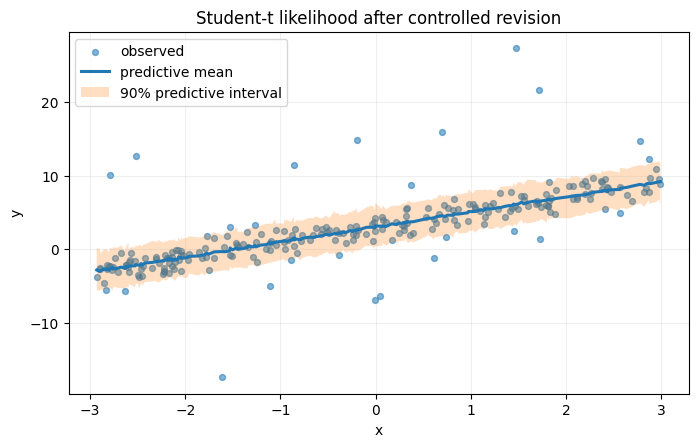

In [17]:
def robust_regression_model(x, y=None, weight_scale=2.5, df=4.0):
    x = torch.as_tensor(x)
    y = None if y is None else torch.as_tensor(y)

    w = pyro.sample(
        "w",
        dist.Normal(torch.zeros(2), weight_scale * torch.ones(2)).to_event(1),
    )
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 0.5))
    mean = w[0] + w[1] * x

    with pyro.plate("data", x.shape[0]):
        pyro.sample("obs", dist.StudentT(df, mean, sigma), obs=y)


pyro.clear_param_store()
robust_guide = AutoNormal(robust_regression_model)
robust_losses = fit_svi(robust_regression_model, robust_guide, x_out, y_out, num_steps=1000)
robust_predictive = Predictive(
    robust_regression_model,
    guide=robust_guide,
    num_samples=500,
    return_sites=("w", "sigma", "obs"),
)
robust_out_draws = robust_predictive(x_out, None)

plot_predictive_fit(
    x_out_np,
    y_out_np,
    robust_out_draws["obs"].detach().cpu().numpy(),
    "Student-t likelihood after controlled revision",
)

In [18]:
comparison = pd.concat(
    {
        "Gaussian": predictive_discrepancy_table(
            x_out_np, y_out_np, gaussian_out_draws["obs"].detach().cpu().numpy()
        ),
        "Student-t": predictive_discrepancy_table(
            x_out_np, y_out_np, robust_out_draws["obs"].detach().cpu().numpy()
        ),
    },
    names=["model", "discrepancy"],
)
comparison.round(3)

observed  replicated median  replicated 5%  \
model     discrepancy                                                       
Gaussian  residual_sd             3.174              3.206          2.811   
          max_abs_residual       20.942              9.467          7.556   
          abs_residual_x_corr     0.025              0.001         -0.104   
Student-t residual_sd             3.174              1.724          1.436   
          max_abs_residual       20.942              7.869          5.367   
          abs_residual_x_corr     0.025             -0.002         -0.108   

                               replicated 95%  
model     discrepancy                          
Gaussian  residual_sd                   3.609  
          max_abs_residual             12.082  
          abs_residual_x_corr           0.108  
Student-t residual_sd                   2.145  
          max_abs_residual             16.132  
          abs_residual_x_corr           0.101

## 10. NumPyro code-along: same model, JAX execution (Extra)

NumPyro retains the familiar `sample`, `plate`, guide, ELBO, and SVI concepts.
The important execution differences are:

- JAX arrays (`jax.numpy`) instead of PyTorch tensors;
- explicit pseudo-random number generator keys;
- functional parameter state returned by SVI;
- JAX compilation and transformations around pure numerical functions.

The statistical model is unchanged.

In [19]:
def numpyro_regression_model(x, y=None, weight_scale=2.5):
    w = numpyro.sample(
        "w",
        ndist.Normal(jnp.zeros(2), weight_scale * jnp.ones(2)).to_event(1),
    )
    sigma = numpyro.sample("sigma", ndist.LogNormal(0.0, 0.5))
    mean = w[0] + w[1] * x

    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("obs", ndist.Normal(mean, sigma), obs=y)

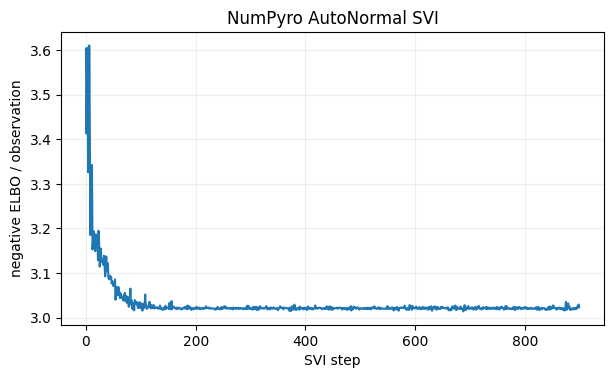

In [20]:
x_jax = jnp.asarray(x_np)
y_jax = jnp.asarray(y_np)

numpyro_guide = NumPyroAutoNormal(numpyro_regression_model)
numpyro_svi = NumPyroSVI(
    numpyro_regression_model,
    numpyro_guide,
    NumPyroAdam(0.03),
    loss=NumPyroTraceELBO(),
)

# NumPyro takes an explicit random key and returns functional parameter state.
result = numpyro_svi.run(
    jax.random.PRNGKey(0),
    900,
    x_jax,
    y_jax,
    progress_bar=False,
)
numpyro_params = result.params

plt.figure(figsize=(7, 3.8))
plt.plot(np.asarray(result.losses) / len(x_np))
plt.xlabel("SVI step")
plt.ylabel("negative ELBO / observation")
plt.title("NumPyro AutoNormal SVI")
plt.grid(alpha=0.2)
plt.show()

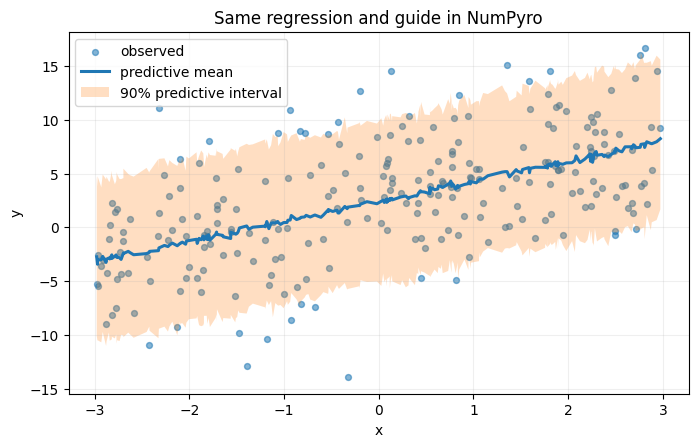

NumPyro posterior mean of w: [2.421 1.865]
NumPyro posterior mean of sigma: 4.563


In [21]:
numpyro_predictive = NumPyroPredictive(
    numpyro_regression_model,
    guide=numpyro_guide,
    params=numpyro_params,
    num_samples=500,
    return_sites=("w", "sigma", "obs"),
)
numpyro_draws = numpyro_predictive(
    jax.random.PRNGKey(1),
    x_jax,
    None,
)

plot_predictive_fit(
    x_np,
    y_np,
    np.asarray(numpyro_draws["obs"]),
    "Same regression and guide in NumPyro",
)

print("NumPyro posterior mean of w:", np.asarray(numpyro_draws["w"]).mean(0).round(3))
print("NumPyro posterior mean of sigma:", np.asarray(numpyro_draws["sigma"]).mean().round(3))

### Pyro → NumPyro: what to notice

| Concept | Pyro | NumPyro |
|---|---|---|
| Arrays | `torch.Tensor` | `jax.Array` |
| Randomness | seeded library state | explicit `jax.random.PRNGKey` |
| Parameters | global `ParamStore` | `result.params` |
| Auto-guide | `pyro.infer.autoguide.AutoNormal` | `numpyro.infer.autoguide.AutoNormal` |
| Objective | `Trace_ELBO()` | `Trace_ELBO()` |
| Predictive sampling | `Predictive(...)` | `Predictive(...)` with explicit key |


## 11. Where amortized inference enters

The `AutoNormal` guide above learns free parameters for **this dataset**. It is not amortized.

Amortized inference replaces free per-dataset parameters with an encoder:

$$
h_\psi(\mathrm D)=(\mu_\psi(\mathrm D),s_\psi(\mathrm D)),
\qquad q_\psi(\theta\mid\mathrm D)
=\mathrm N(\mu_\psi(\mathrm D),\operatorname{diag}s_\psi^2(\mathrm D)).
$$

The same $\psi$ is reused across datasets. The workflow cost moves to prior-data simulation, encoder design, calibration, and distribution-shift detection.

## 12. Takeaways

1. `sample`, `obs`, and `plate` make a probabilistic model executable.
2. A guide is an explicit approximation with support, factorization, and geometry assumptions.
3. SVI optimizes the ELBO;
4. Prior and posterior predictive checks criticize implications of the whole generative story.
5. Robust revision should change an identified assumption.
6. Pyro and NumPyro preserve the modeling language while changing tensor, state, randomness, and compilation semantics.
7. Amortized inference learns a reusable data-to-posterior operator.

## Questions for further discussions and reflection

- What would a full-covariance guide change?
- What would it mean for an agent to maintain uncertainty over model revisions rather than merely retry code?